X shape: (580, 20, 1)
y shape: (580, 1)

===== TRAIN RNN =====
Epoch [10/100] Train Loss: 0.027301 Val Loss: 0.025081
Epoch [20/100] Train Loss: 0.009044 Val Loss: 0.010170
Epoch [30/100] Train Loss: 0.007510 Val Loss: 0.008821
Epoch [40/100] Train Loss: 0.006984 Val Loss: 0.008506
Epoch [50/100] Train Loss: 0.006475 Val Loss: 0.008564
Epoch [60/100] Train Loss: 0.006063 Val Loss: 0.008472
Epoch [70/100] Train Loss: 0.005628 Val Loss: 0.007622
Epoch [80/100] Train Loss: 0.005097 Val Loss: 0.006534
Epoch [90/100] Train Loss: 0.004995 Val Loss: 0.006380
Epoch [100/100] Train Loss: 0.004933 Val Loss: 0.006322

===== TRAIN LSTM =====
Epoch [10/100] Train Loss: 0.022589 Val Loss: 0.020925
Epoch [20/100] Train Loss: 0.004650 Val Loss: 0.005720
Epoch [30/100] Train Loss: 0.004582 Val Loss: 0.005758
Epoch [40/100] Train Loss: 0.004551 Val Loss: 0.005773
Epoch [50/100] Train Loss: 0.004530 Val Loss: 0.005779
Epoch [60/100] Train Loss: 0.004514 Val Loss: 0.005782
Epoch [70/100] Train Loss: 0.004

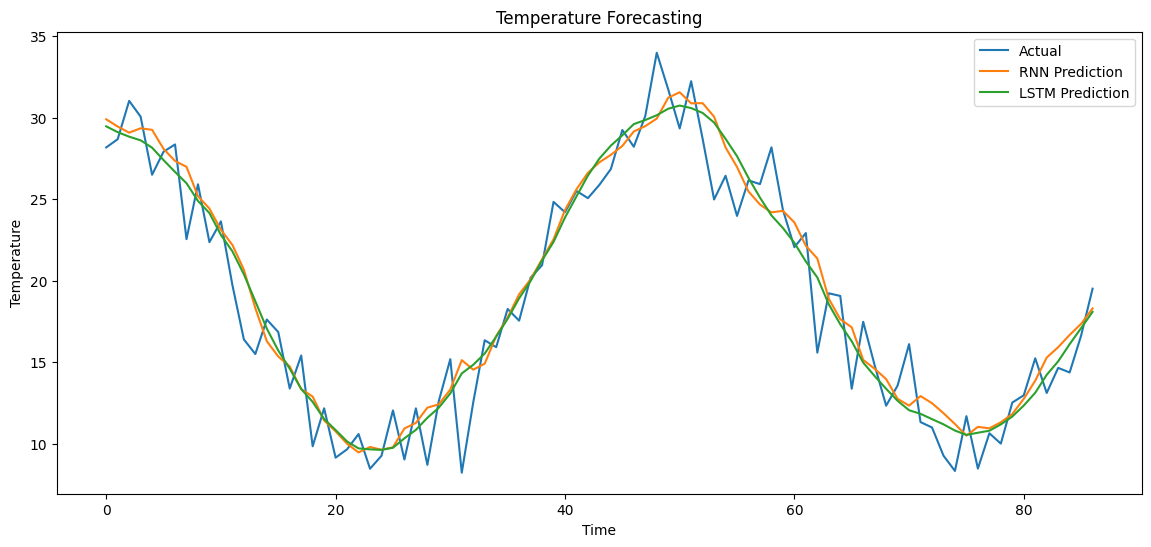

In [1]:


import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# =========================
# 1. Tạo dữ liệu nhiệt độ giả lập
# =========================

np.random.seed(42)

n_points = 600
t = np.arange(n_points)

# nhiệt độ có tính chu kỳ + nhiễu
temperature = (
    20
    + 10 * np.sin(2 * np.pi * t / 50)
    + 2 * np.random.randn(n_points)
)

temperature = temperature.reshape(-1, 1)

# =========================
# 2. Chuẩn hóa Min-Max
# =========================

scaler = MinMaxScaler()
temperature_scaled = scaler.fit_transform(temperature)

# =========================
# 3. Tạo sliding window
# =========================

seq_length = 20

X = []
y = []

for i in range(len(temperature_scaled) - seq_length):
    X.append(temperature_scaled[i:i+seq_length])
    y.append(temperature_scaled[i+seq_length])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================
# 4. Chia train/val/test
# =========================

total = len(X)

train_size = int(total * 0.7)
val_size = int(total * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

# =========================
# 5. Chuyển sang Tensor
# =========================

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

# =========================
# 6. DataLoader
# =========================

batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=False
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

# =========================
# 7. RNN Model
# =========================

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super(RNNModel, self).__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        output, h_n = self.rnn(x)

        # lấy hidden state cuối
        out = output[:, -1, :]

        out = self.fc(out)

        return out

# =========================
# 8. LSTM Model
# =========================

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        output, (h_n, c_n) = self.lstm(x)

        # lấy output cuối
        out = output[:, -1, :]

        out = self.fc(out)

        return out

# =========================
# 9. Hàm train
# =========================

def train_model(model, train_loader, val_loader, epochs=100):

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # train
        model.train()

        train_loss = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            pred = model(X_batch)

            loss = criterion(pred, y_batch)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # validation
        model.eval()

        val_loss = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                pred = model(X_batch)

                loss = criterion(pred, y_batch)

                val_loss += loss.item()

        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch+1}/{epochs}] "
                f"Train Loss: {train_loss:.6f} "
                f"Val Loss: {val_loss:.6f}"
            )

    return train_losses, val_losses

# =========================
# 10. Train RNN
# =========================

print("\n===== TRAIN RNN =====")

rnn_model = RNNModel()

rnn_train_loss, rnn_val_loss = train_model(
    rnn_model,
    train_loader,
    val_loader
)

# =========================
# 11. Train LSTM
# =========================

print("\n===== TRAIN LSTM =====")

lstm_model = LSTMModel()

lstm_train_loss, lstm_val_loss = train_model(
    lstm_model,
    train_loader,
    val_loader
)

# =========================
# 12. Đánh giá trên test
# =========================

def evaluate(model, X_test, y_test):

    model.eval()

    with torch.no_grad():
        pred = model(X_test).numpy()

    y_true = y_test.numpy()

    mse = mean_squared_error(y_true, pred)

    return mse, pred

rnn_mse, rnn_pred = evaluate(rnn_model, X_test, y_test)
lstm_mse, lstm_pred = evaluate(lstm_model, X_test, y_test)

print("\n===== TEST RESULT =====")
print(f"RNN Test MSE  : {rnn_mse:.6f}")
print(f"LSTM Test MSE : {lstm_mse:.6f}")

# =========================
# 13. Inverse transform
# =========================

y_true_inv = scaler.inverse_transform(y_test.numpy())

rnn_pred_inv = scaler.inverse_transform(rnn_pred)

lstm_pred_inv = scaler.inverse_transform(lstm_pred)

# =========================
# 14. Plot kết quả
# =========================

plt.figure(figsize=(14,6))

plt.plot(y_true_inv, label='Actual')

plt.plot(rnn_pred_inv, label='RNN Prediction')

plt.plot(lstm_pred_inv, label='LSTM Prediction')

plt.title('Temperature Forecasting')

plt.xlabel('Time')

plt.ylabel('Temperature')

plt.legend()

plt.show()

In [ ]:
import re
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from collections import Counter

import nltk
from nltk.tokenize import word_tokenize

# =========================
# Download tokenizer
# =========================

nltk.download('punkt')

# =========================
# 1. Load dataset
# =========================
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
print(df.head())

# lấy 1000 mẫu
df = df.sample(1000, random_state=42)

texts = df["review"].values
labels = df["sentiment"].values

# positive = 1, negative = 0
labels = np.array([
    1 if x == "positive" else 0
    for x in labels
])

# =========================
# 2. Clean text
# =========================

def clean_text(text):

    text = text.lower()

    # bỏ html
    text = re.sub(r"<.*?>", "", text)

    # bỏ ký tự đặc biệt
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text

# =========================
# 3. Tokenization
# =========================

tokenized_texts = []

for text in texts:

    text = clean_text(text)

    tokens = word_tokenize(text)

    tokenized_texts.append(tokens)

# =========================
# 4. Build vocabulary
# =========================

counter = Counter()

for tokens in tokenized_texts:
    counter.update(tokens)

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, freq in counter.items():

    # chỉ giữ từ xuất hiện >=2 lần
    if freq >= 2:
        vocab[word] = len(vocab)

print("Vocab size:", len(vocab))

# =========================
# 5. Encode text -> số
# =========================

encoded_texts = []

for tokens in tokenized_texts:

    encoded = []

    for token in tokens:

        encoded.append(
            vocab.get(token, vocab["<UNK>"])
        )

    encoded_texts.append(encoded)

# =========================
# 6. Padding
# =========================

MAX_LEN = 100

def pad_sequence(seq, max_len):

    if len(seq) < max_len:

        seq = seq + [0] * (max_len - len(seq))

    else:

        seq = seq[:max_len]

    return seq

padded_texts = np.array([
    pad_sequence(seq, MAX_LEN)
    for seq in encoded_texts
])

# =========================
# 7. Train / Val / Test split
# =========================

X_train, X_temp, y_train, y_temp = train_test_split(
    padded_texts,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# =========================
# 8. Dataset class
# =========================

class SentimentDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.LongTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x = self.X[idx]

        # đếm số token khác PAD
        length = (x != 0).sum()

        return x, length, self.y[idx]

# =========================
# 9. DataLoader
# =========================

batch_size = 32

train_loader = DataLoader(
    SentimentDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    SentimentDataset(X_val, y_val),
    batch_size=batch_size
)

test_loader = DataLoader(
    SentimentDataset(X_test, y_test),
    batch_size=batch_size
)

# =========================
# 10. LSTM Model
# =========================

class LSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3
    ):

        super().__init__()

        # Embedding
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        # LSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Fully connected
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):

        # Embedding
        embedded = self.embedding(x)

        # Pack padded
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        # LSTM
        packed_output, (h_n, c_n) = self.lstm(packed)

        # hidden cuối
        hidden = h_n[-1]

        hidden = self.dropout(hidden)

        output = self.fc(hidden)

        return output.squeeze()

# =========================
# 11. Bidirectional LSTM
# =========================

class BiLSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        num_layers=2,
        dropout=0.3
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)

        # hidden_dim * 2 vì bidirectional
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, lengths):

        embedded = self.embedding(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, (h_n, c_n) = self.lstm(packed)

        # concat forward + backward
        hidden = torch.cat(
            (h_n[-2], h_n[-1]),
            dim=1
        )

        hidden = self.dropout(hidden)

        output = self.fc(hidden)

        return output.squeeze()

# =========================
# 12. Device
# =========================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# =========================
# 13. Train function
# =========================

def train_model(model, train_loader, val_loader, epochs=10):

    model.to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    for epoch in range(epochs):

        # ===== TRAIN =====
        model.train()

        train_loss = 0

        for x, lengths, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            outputs = model(x, lengths)

            loss = criterion(outputs, y)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        # ===== VALIDATION =====
        model.eval()

        preds = []
        truths = []

        with torch.no_grad():

            for x, lengths, y in val_loader:

                x = x.to(device)

                outputs = model(x, lengths)

                probs = torch.sigmoid(outputs)

                predicted = (probs >= 0.5).int()

                preds.extend(
                    predicted.cpu().numpy()
                )

                truths.extend(
                    y.numpy()
                )

        acc = accuracy_score(truths, preds)

        f1 = f1_score(truths, preds)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Acc: {acc:.4f} | "
            f"F1: {f1:.4f}"
        )

# =========================
# 14. Evaluate function
# =========================

def evaluate(model, test_loader):

    model.eval()

    preds = []
    truths = []

    with torch.no_grad():

        for x, lengths, y in test_loader:

            x = x.to(device)

            outputs = model(x, lengths)

            probs = torch.sigmoid(outputs)

            predicted = (probs >= 0.5).int()

            preds.extend(
                predicted.cpu().numpy()
            )

            truths.extend(
                y.numpy()
            )

    acc = accuracy_score(truths, preds)

    f1 = f1_score(truths, preds)

    return acc, f1

# =========================
# 15. Train LSTM
# =========================

print("\n===== TRAIN LSTM =====")

model = LSTMClassifier(
    vocab_size=len(vocab)
)

train_model(
    model,
    train_loader,
    val_loader,
    epochs=10
)

# =========================
# 16. Evaluate LSTM
# =========================

acc, f1 = evaluate(model, test_loader)

print("\n===== LSTM RESULT =====")

print("Accuracy:", acc)

print("F1 Score:", f1)

# =========================
# 17. Train BiLSTM
# =========================

print("\n===== TRAIN BiLSTM =====")

bilstm_model = BiLSTMClassifier(
    vocab_size=len(vocab)
)

train_model(
    bilstm_model,
    train_loader,
    val_loader,
    epochs=10
)

# =========================
# 18. Evaluate BiLSTM
# =========================

acc2, f12 = evaluate(
    bilstm_model,
    test_loader
)

print("\n===== BiLSTM RESULT =====")

print("Accuracy:", acc2)

print("F1 Score:", f12)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


TypeError: 'NoneType' object is not subscriptable

In [9]:
import torch
import torch.nn as nn
import numpy as np

# =========================
# 1. LOAD DATA
# =========================

with open("truyen_kieu.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Độ dài văn bản:", len(text))

# =========================
# 2. VOCAB
# =========================

chars = sorted(list(set(text)))

vocab_size = len(chars)

print("Số ký tự khác nhau:", vocab_size)

char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for i, ch in enumerate(chars)}

# Encode toàn bộ text thành số
encoded_text = [char2idx[ch] for ch in text]

# =========================
# 3. TẠO DATASET
# =========================

seq_length = 50

X = []
Y = []

for i in range(len(encoded_text) - seq_length):

    x_seq = encoded_text[i:i + seq_length]
    y_char = encoded_text[i + seq_length]

    X.append(x_seq)
    Y.append(y_char)

X = torch.tensor(X, dtype=torch.long)
Y = torch.tensor(Y, dtype=torch.long)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# =========================
# 4. MODEL LSTM
# =========================

class CharLSTM(nn.Module):

    def __init__(self, vocab_size,
                 embed_size=64,
                 hidden_size=128,
                 num_layers=2):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):

        # x: (batch, seq_len)

        x = self.embedding(x)

        # out: (batch, seq_len, hidden)
        out, _ = self.lstm(x)

        # lấy output cuối cùng
        out = out[:, -1, :]

        out = self.fc(out)

        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CharLSTM(vocab_size).to(device)

# =========================
# 5. TRAIN
# =========================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

batch_size = 64
epochs = 50

for epoch in range(epochs):

    permutation = torch.randperm(X.size(0))

    total_loss = 0

    for i in range(0, X.size(0), batch_size):

        indices = permutation[i:i + batch_size]

        batch_x = X[indices].to(device)
        batch_y = Y[indices].to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

# =========================
# 6. GENERATE TEXT
# =========================

def generate_text(model,
                  seed_text,
                  length=300,
                  temperature=1.0):

    model.eval()

    generated = seed_text

    for _ in range(length):

        # lấy 50 ký tự cuối
        input_seq = generated[-seq_length:]

        # nếu ngắn hơn 50 thì pad
        if len(input_seq) < seq_length:
            input_seq = " " * (seq_length - len(input_seq)) + input_seq

        input_ids = [char2idx.get(ch, 0) for ch in input_seq]

        x = torch.tensor([input_ids], dtype=torch.long).to(device)

        with torch.no_grad():
            logits = model(x)

        logits = logits / temperature

        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

        # sample theo phân phối xác suất
        next_idx = np.random.choice(vocab_size, p=probs)

        next_char = idx2char[next_idx]

        generated += next_char

    return generated

# =========================
# 7. TEST
# =========================

seed = "Trăm năm trong cõi"

result = generate_text(
    model,
    seed_text=seed,
    length=500,
    temperature=0.8
)

print(result)

Độ dài văn bản: 524
Số ký tự khác nhau: 83
X shape: torch.Size([474, 50])
Y shape: torch.Size([474])
Epoch 1/50 - Loss: 34.9186
Epoch 2/50 - Loss: 31.4489
Epoch 3/50 - Loss: 28.4352
Epoch 4/50 - Loss: 27.9350
Epoch 5/50 - Loss: 27.9598
Epoch 6/50 - Loss: 27.5404
Epoch 7/50 - Loss: 27.1338
Epoch 8/50 - Loss: 26.8687
Epoch 9/50 - Loss: 26.2662
Epoch 10/50 - Loss: 25.2461
Epoch 11/50 - Loss: 24.7500
Epoch 12/50 - Loss: 23.8182
Epoch 13/50 - Loss: 23.2683
Epoch 14/50 - Loss: 22.1464
Epoch 15/50 - Loss: 21.8877
Epoch 16/50 - Loss: 20.5364
Epoch 17/50 - Loss: 20.2678
Epoch 18/50 - Loss: 19.8259
Epoch 19/50 - Loss: 19.2092
Epoch 20/50 - Loss: 18.8144
Epoch 21/50 - Loss: 18.3683
Epoch 22/50 - Loss: 17.4348
Epoch 23/50 - Loss: 17.2795
Epoch 24/50 - Loss: 16.5060
Epoch 25/50 - Loss: 15.8935
Epoch 26/50 - Loss: 15.6634
Epoch 27/50 - Loss: 15.0862
Epoch 28/50 - Loss: 14.8428
Epoch 29/50 - Loss: 14.4512
Epoch 30/50 - Loss: 14.0388
Epoch 31/50 - Loss: 13.5839
Epoch 32/50 - Loss: 12.9014
Epoch 33/50 

In [7]:
text = """
Trăm năm trong cõi người ta,
Chữ tài chữ mệnh khéo là ghét nhau.
Trải qua một cuộc bể dâu,
Những điều trông thấy mà đau đớn lòng.

Lạ gì bỉ sắc tư phong,
Trời xanh quen thói má hồng đánh ghen.
Cảo thơm lần giở trước đèn,
Phong tình cổ lục còn truyền sử xanh.

Rằng năm Gia Tĩnh triều Minh,
Bốn phương phẳng lặng hai kinh vững vàng.
Có nhà viên ngoại họ Vương,
Gia tư nghĩ cũng thường thường bậc trung.

Một trai con thứ rốt lòng,
Vương Quan là chữ nối dòng nho gia.
Đầu lòng hai ả tố nga,
Thúy Kiều là chị, em là Thúy Vân.
"""

with open("truyen_kieu.txt", "w", encoding="utf-8") as f:
    f.write(text)

print("Đã tạo file truyen_kieu.txt")

Đã tạo file truyen_kieu.txt


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
